### Deep Learning e Autoencoder

Este notebook tem como objetivo avançar a modelagem do projeto usando técnicas de Deep Learning.

No notebook anterior, foram treinados modelos clássicos de Machine Learning, e o `Random Forest` apresentou o melhor desempenho entre os baselines. Agora, vamos testar uma rede neural MLP para avaliar se um modelo de Deep Learning consegue capturar padrões mais complexos nos dados.

Além da MLP, este notebook também vai introduzir o uso de `Autoencoder`, uma rede neural capaz de aprender uma representação mais compacta dos dados. Essa representação será importante para a próxima etapa do projeto, pois poderá ser usada no experimento de Quantum Machine Learning.

Nesta etapa, vamos trabalhar com:

- preparação dos dados para Deep Learning;
- codificação da variável-alvo;
- normalização das variáveis;
- treinamento de uma MLP;
- uso de `epochs`, `batch_size` e validação;
- avaliação do modelo;
- criação de um Autoencoder;
- extração do `latent space`, ou espaço latente.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/koi_selected_initial.csv")

df.head()

,kepid,kepoi_name,koi_disposition,koi_period,koi_duration,koi_depth,koi_num_transits,koi_model_snr,koi_prad,koi_teq,koi_insol,koi_steff,koi_slogg,koi_srad,koi_smass,koi_kepmag,ra,dec
0,10797460,K00752.01,CONFIRMED,9.488036,2.95750,615.8,142.0,35.8,2.26,793.0,93.59,5455.0,4.467,0.927,0.919,15.347,291.93423,48.141651
1,10797460,K00752.02,CONFIRMED,54.418383,4.50700,874.8,25.0,25.8,2.83,443.0,9.11,5455.0,4.467,0.927,0.919,15.347,291.93423,48.141651
2,10811496,K00753.01,CANDIDATE,19.899140,1.78220,10829.0,56.0,76.3,14.60,638.0,39.30,5853.0,4.544,0.868,0.961,15.436,297.00482,48.134129
3,10848459,K00754.01,FALSE POSITIVE,1.736952,2.40641,8079.2,621.0,505.6,33.46,1395.0,891.96,5805.0,4.564,0.791,0.836,15.597,285.53461,48.285210
4,10854555,K00755.01,CONFIRMED,2.525592,1.65450,603.3,515.0,40.9,2.75,1406.0,926.16,6031.0,4.438,1.046,1.095,15.509,288.75488,48.226200


### Preparação das variáveis para Deep Learning

In [3]:
target_column = "koi_disposition"

identifier_columns = [
    "kepid",
    "kepoi_name"
]

feature_columns = [
    column for column in df.columns
    if column not in identifier_columns + [target_column]
]

X = df[feature_columns].copy()
y = df[target_column].copy()

print("Quantidade de variáveis de entrada:", X.shape[1])
print("Quantidade de registros:", X.shape[0])
print("Variável-alvo:", target_column)

Quantidade de variáveis de entrada: 15
Quantidade de registros: 9564
Variável-alvo: koi_disposition


### Análise da preparação das variáveis

A preparação dos dados resultou em 15 variáveis de entrada e 9.564 registros.

Assim como no notebook de Machine Learning, as colunas `kepid` e `kepoi_name` foram mantidas fora das variáveis de entrada, pois servem apenas para identificação dos objetos.

A variável-alvo continua sendo `koi_disposition`, que representa a classificação dos objetos como `CANDIDATE`, `CONFIRMED` ou `FALSE POSITIVE`.

Essa separação mantém o mesmo padrão usado nos modelos baseline, permitindo uma comparação mais justa entre Machine Learning clássico e Deep Learning.

### Tratamento de valores ausentes e codificação da variável-alvo

In [4]:
from sklearn.preprocessing import LabelEncoder

X = X.fillna(X.median())

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

class_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

print("Valores ausentes em X:", X.isna().sum().sum())
print("Mapeamento das classes:", class_mapping)

Valores ausentes em X: 0
Mapeamento das classes: {'CANDIDATE': np.int64(0), 'CONFIRMED': np.int64(1), 'FALSE POSITIVE': np.int64(2)}


### Separação entre treino, teste e normalização dos dados

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train_scaled: (7651, 15)
X_test_scaled: (1913, 15)
y_train: (7651,)
y_test: (1913,)


### Importação das bibliotecas de Deep Learning

In [7]:
%pip install tensorflow

  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached charset_normalizer-3.4.7-cp312-cp312-macosx_10_13_universal2.whl.metadata (40 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached markdown_it_py-4.2.0-py3-none-any.whl.metadata (7.4 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.5/223.5 MB 27.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 36.2 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 39.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 34.2 MB/s eta 0:00:00
Using cached requests-2.34.2-py3-none-any.whl (73 kB)
Using cach

In [8]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

### Construção do modelo MLP

In [9]:
mlp_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(3, activation="softmax")
])

mlp_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mlp_model.summary()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,203 (12.51 KB)

 Trainable params: 3,203 (12.51 KB)

 Non-trainable params: 0 (0.00 B)

### Justificativa das funções de ativação

Nas camadas internas da MLP foi usada a função de ativação `ReLU`, pois ela ajuda a rede neural a aprender relações não lineares entre as variáveis. Isso é importante porque a separação entre `CANDIDATE`, `CONFIRMED` e `FALSE POSITIVE` depende da combinação de várias características observacionais, e não apenas de uma variável isolada.

Na camada final foi usada a função `softmax`, pois o problema possui três classes. A `softmax` transforma a saída da rede em probabilidades para cada classe, permitindo que o modelo escolha a classificação mais provável para cada objeto.

In [10]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_mlp = mlp_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5859 - loss: 0.8935 - val_accuracy: 0.6336 - val_loss: 0.8027
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step - accuracy: 0.6376 - loss: 0.8133 - val_accuracy: 0.6486 - val_loss: 0.7741
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step - accuracy: 0.6482 - loss: 0.7882 - val_accuracy: 0.6558 - val_loss: 0.7582
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 755us/step - accuracy: 0.6560 - loss: 0.7708 - val_accuracy: 0.6623 - val_loss: 0.7451
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - accuracy: 0.6644 - loss: 0.7555 - val_accuracy: 0.6695 - val_loss: 0.7319
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6706 - loss: 0.7495 - val_accuracy: 0.6715 - val_loss: 0.7281
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - accuracy: 0.6765 - loss: 0.7409 - val_accuracy: 0.6754 - val_loss: 0.7209
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step - accuracy: 0.6859 - loss: 0.726

### Visualização do treinamento da MLP

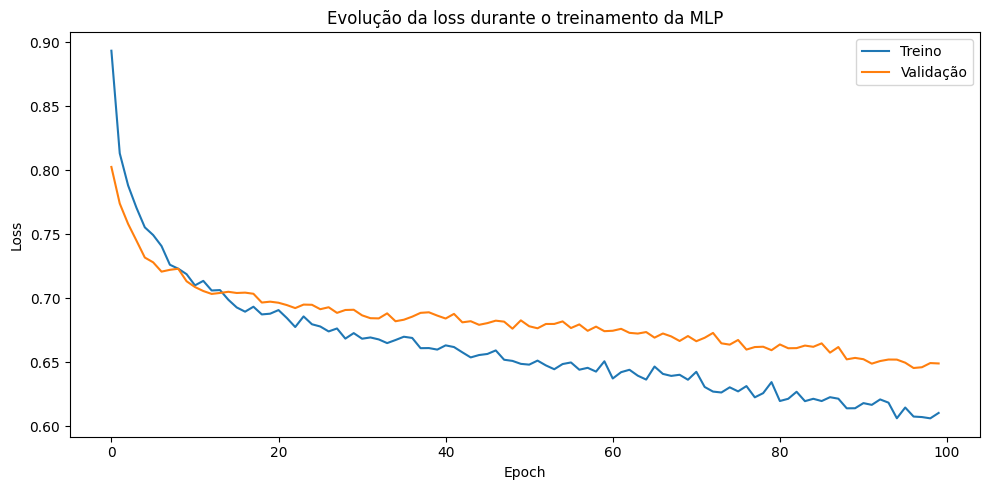

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(history_mlp.history["loss"], label="Treino")
plt.plot(history_mlp.history["val_loss"], label="Validação")

plt.title("Evolução da loss durante o treinamento da MLP")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### Análise da loss durante o treinamento da MLP

O gráfico mostra que a `loss` de treino e validação diminuiu ao longo das epochs, indicando que a MLP conseguiu aprender padrões nos dados.

A curva de treino caiu de forma contínua, enquanto a curva de validação também reduziu, mas de maneira mais lenta. Isso é esperado, porque o modelo costuma se ajustar melhor aos dados usados diretamente no treinamento.

A diferença entre as curvas não parece extrema, então não há um sinal forte de `overfitting` nesta etapa. Mesmo assim, a curva de treino ficou consistentemente abaixo da curva de validação, o que indica que o modelo aprende melhor no conjunto de treino do que em dados separados para validação.

O uso de `EarlyStopping` ajuda a controlar esse comportamento, interrompendo o treinamento caso a validação pare de melhorar por várias epochs. Isso evita que a rede continue treinando apenas para memorizar os dados de treino.

### Visualização da accuracy durante o treinamento da MLP

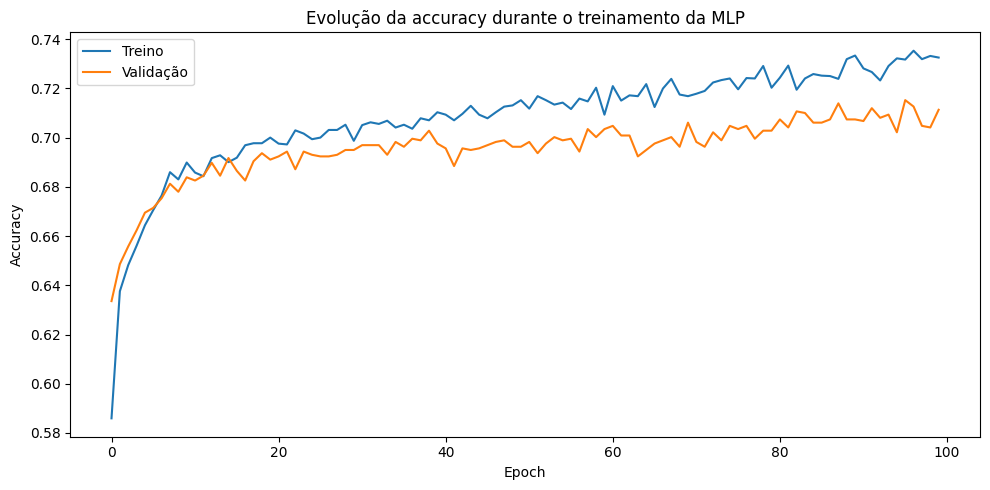

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(history_mlp.history["accuracy"], label="Treino")
plt.plot(history_mlp.history["val_accuracy"], label="Validação")

plt.title("Evolução da accuracy durante o treinamento da MLP")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


### Análise da accuracy durante o treinamento da MLP

O gráfico mostra que a accuracy da MLP aumentou ao longo das epochs, tanto no conjunto de treino quanto no conjunto de validação.

No início, o modelo ainda estava aprendendo os padrões principais dos dados. Depois das primeiras epochs, a curva de validação estabilizou em torno de 70% a 71%, enquanto a curva de treino continuou subindo até aproximadamente 73%.

Essa diferença entre treino e validação indica que a rede está aprendendo melhor os dados de treino do que os dados de validação, mas a diferença ainda não parece muito alta. Portanto, há um pequeno sinal de `overfitting`, mas não algo extremo nesta primeira versão.

O resultado mostra que a MLP conseguiu aprender padrões relevantes, mas ainda precisamos avaliar o modelo no conjunto de teste para comparar seu desempenho com os modelos baseline, principalmente com o `Random Forest`.

### Avaliação da MLP no conjunto de teste

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_mlp_prob = mlp_model.predict(X_test_scaled)

y_pred_mlp = np.argmax(y_pred_mlp_prob, axis=1)

accuracy_mlp = accuracy_score(y_test, y_pred_mlp)

print("Accuracy:", round(accuracy_mlp, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=label_encoder.classes_))

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.7261

Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.52      0.22      0.31       396
     CONFIRMED       0.68      0.82      0.74       549
FALSE POSITIVE       0.79      0.88      0.83       968

      accuracy                           0.73      1913
     macro avg       0.66      0.64      0.63      1913
  weighted avg       0.70      0.73      0.70      1913



### Análise da MLP no conjunto de teste

A MLP apresentou accuracy de 72,61% no conjunto de teste. Esse resultado ficou acima da `Logistic Regression` e do `SVM`, mas abaixo do `Random Forest`, que continua sendo o melhor modelo até esta etapa.

A classe `FALSE POSITIVE` teve o melhor desempenho, com F1-score de 0,83. Isso indica que a rede conseguiu reconhecer bem muitos padrões associados a falsos positivos.

A classe `CONFIRMED` também teve um resultado razoável, com F1-score de 0,74. O recall de 0,82 mostra que a MLP conseguiu identificar boa parte dos planetas confirmados.

O principal problema apareceu novamente na classe `CANDIDATE`, que teve recall de apenas 0,22 e F1-score de 0,31. Isso significa que muitos candidatos reais foram classificados como outras classes. Esse comportamento já era esperado em parte, porque a classe `CANDIDATE` representa objetos que ainda não possuem confirmação definitiva e podem ter características parecidas tanto com `CONFIRMED` quanto com `FALSE POSITIVE`.

Comparando com os modelos baseline, a MLP mostrou capacidade de aprendizado, mas ainda não superou o `Random Forest`. Isso sugere que, para esta primeira versão do dataset tabular, o modelo baseado em árvores conseguiu lidar melhor com os padrões das variáveis.

Nas próximas etapas, será possível testar ajustes na rede neural, como `class_weight`, mudanças na arquitetura ou uso de representações aprendidas por Autoencoder.

### Matriz de confusão da MLP

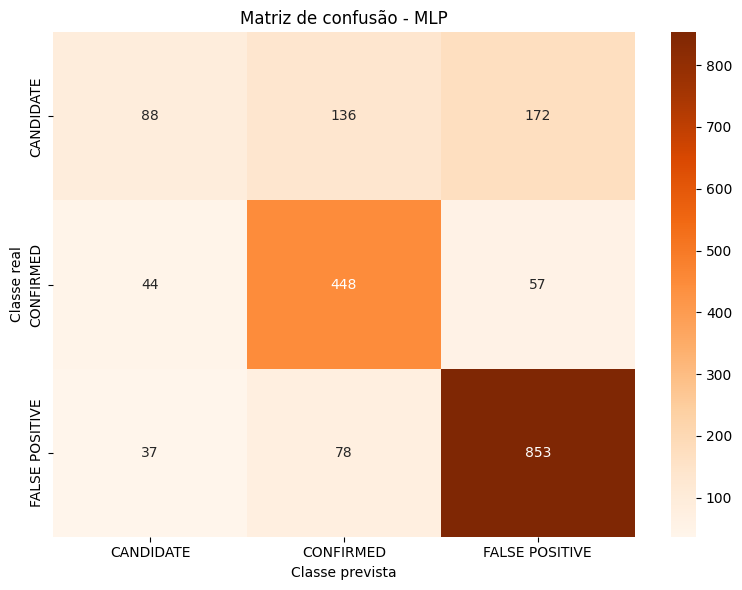

In [14]:
conf_matrix_mlp = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix_mlp,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Matriz de confusão - MLP")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")

plt.tight_layout()
plt.show()

### Análise da matriz de confusão da MLP

A matriz de confusão da MLP mostra que o modelo teve bom desempenho para a classe `FALSE POSITIVE`, mas ainda apresentou dificuldade para reconhecer a classe `CANDIDATE`.

Na classe `FALSE POSITIVE`, a MLP classificou corretamente 853 dos 968 exemplos. Esse foi o melhor resultado da rede, indicando que ela conseguiu identificar bem muitos sinais associados a falsos positivos.

Na classe `CONFIRMED`, o modelo também apresentou um resultado razoável, com 448 acertos em 549 exemplos. Isso mostra que a rede conseguiu reconhecer boa parte dos planetas confirmados.

O principal problema está na classe `CANDIDATE`. Dos 396 candidatos reais, apenas 88 foram classificados corretamente. Muitos candidatos foram confundidos com `CONFIRMED` ou `FALSE POSITIVE`, o que reforça que essa classe é a mais difícil do problema.

Comparando com o `Random Forest`, a MLP acertou mais falsos positivos, mas teve desempenho pior na identificação de candidatos. Como o objetivo do projeto envolve priorização de candidatos a exoplanetas, esse ponto é importante e mostra que apenas aumentar o acerto geral não é suficiente. Precisamos observar também o equilíbrio entre as classes.

Esse resultado sugere que a próxima melhoria deve focar no tratamento do `class imbalance`, usando `class_weight` no treinamento da rede neural.

### Cálculo dos pesos das classes

In [15]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(zip(np.unique(y_train), class_weights))

class_weight_dict

{np.int64(0): np.float64(1.612094395280236),
 np.int64(1): np.float64(1.1602972399150744),
 np.int64(2): np.float64(0.6588306208559374)}

### Treinamento da MLP com class weight

In [16]:
mlp_weighted_model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(3, activation="softmax")
])

mlp_weighted_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping_weighted = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_mlp_weighted = mlp_weighted_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_weighted],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/100


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5328 - loss: 0.9766 - val_accuracy: 0.5898 - val_loss: 0.8756
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 750us/step - accuracy: 0.5825 - loss: 0.9047 - val_accuracy: 0.6022 - val_loss: 0.8456
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 741us/step - accuracy: 0.6018 - loss: 0.8697 - val_accuracy: 0.6029 - val_loss: 0.8523
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 735us/step - accuracy: 0.6056 - loss: 0.8696 - val_accuracy: 0.6212 - val_loss: 0.8139
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 748us/step - accuracy: 0.6191 - loss: 0.8451 - val_accuracy: 0.6172 - val_loss: 0.8269
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step - accuracy: 0.6289 - loss: 0.8337 - val_accuracy: 0.6303 - val_loss: 0.8097
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 746us/step - accuracy: 0.6332 - loss: 0.8329 - val_accuracy: 0.6290 - val_loss: 0.7977
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 902us/step - accuracy: 0.6379 - loss: 0.8167 - val_ac

In [17]:
y_pred_mlp_weighted_prob = mlp_weighted_model.predict(X_test_scaled)

y_pred_mlp_weighted = np.argmax(y_pred_mlp_weighted_prob, axis=1)

accuracy_mlp_weighted = accuracy_score(y_test, y_pred_mlp_weighted)

print("Accuracy:", round(accuracy_mlp_weighted, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp_weighted, target_names=label_encoder.classes_))

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 688us/step
Accuracy: 0.6796

Classification Report:
                precision    recall  f1-score   support

     CANDIDATE       0.40      0.46      0.43       396
     CONFIRMED       0.64      0.82      0.72       549
FALSE POSITIVE       0.89      0.69      0.78       968

      accuracy                           0.68      1913
     macro avg       0.64      0.66      0.64      1913
  weighted avg       0.72      0.68      0.69      1913



### Análise da MLP com class weight

A MLP com `class_weight` apresentou accuracy de 67,96%, ficando abaixo da primeira MLP, que havia alcançado 72,61%.

Apesar da queda na accuracy geral, o comportamento do modelo mudou de forma importante. A classe `CANDIDATE`, que era o principal ponto fraco da primeira MLP, teve melhora no recall, passando de 0,22 para 0,46. Isso significa que o modelo passou a identificar mais candidatos reais.

Por outro lado, essa melhora teve um custo. A precision da classe `CANDIDATE` ficou em 0,40, indicando que o modelo também passou a classificar mais objetos de outras classes como candidatos. Além disso, a classe `FALSE POSITIVE` teve queda no recall, passando a identificar menos falsos positivos corretamente.

Esse resultado mostra um trade-off importante: ao dar mais peso para a classe menos representada, o modelo ficou mais sensível aos candidatos, mas perdeu desempenho geral e parte da capacidade de identificar falsos positivos.

Para o objetivo do projeto, esse resultado é relevante. Como queremos discutir priorização de candidatos a exoplanetas, aumentar o recall da classe `CANDIDATE` pode ser interessante, mesmo que a accuracy geral diminua. Ainda assim, o `Random Forest` continua sendo o melhor modelo geral até agora.

### Matriz de confusão da MLP com class weight

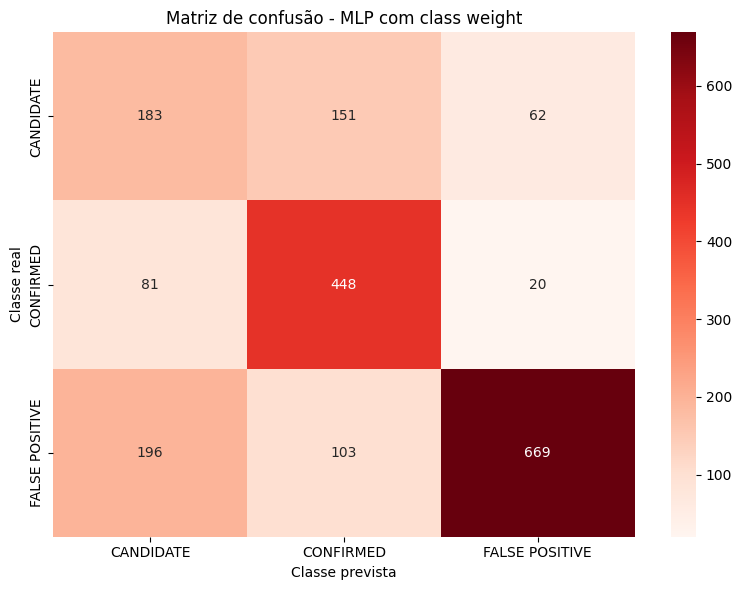

In [18]:
conf_matrix_mlp_weighted = confusion_matrix(y_test, y_pred_mlp_weighted)

plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix_mlp_weighted,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Matriz de confusão - MLP com class weight")
plt.xlabel("Classe prevista")
plt.ylabel("Classe real")

plt.tight_layout()
plt.show()

### Análise da matriz de confusão da MLP com class weight

A matriz de confusão mostra que o uso de `class_weight` mudou o comportamento da MLP.

Na classe `CANDIDATE`, o modelo acertou 183 dos 396 exemplos. Esse resultado é bem melhor que o da MLP anterior, que havia acertado apenas 88 candidatos. Isso confirma que o `class_weight` ajudou a rede a prestar mais atenção na classe menos representada.

Por outro lado, esse ganho trouxe um custo. O modelo passou a classificar mais objetos como `CANDIDATE`, incluindo 196 casos que eram `FALSE POSITIVE`. Esse aumento de falsos positivos classificados como candidatos pode ser um problema em um sistema de priorização, pois objetos menos promissores poderiam receber atenção indevida.

A classe `CONFIRMED` manteve desempenho parecido, com 448 acertos. Já a classe `FALSE POSITIVE` teve queda em relação à MLP anterior, passando de 853 para 669 acertos.

Esse resultado mostra um trade-off importante: o `class_weight` melhorou a identificação de candidatos, mas reduziu a capacidade do modelo de reconhecer falsos positivos. Para o projeto, essa comparação é relevante porque mostra que a escolha do modelo depende do objetivo. Se a prioridade for encontrar mais candidatos, o modelo com `class_weight` pode ser útil. Se a prioridade for equilíbrio geral, o `Random Forest` ainda parece mais adequado.

### Comparação entre modelos clássicos e MLP

In [19]:
deep_learning_results = pd.DataFrame({
    "model": [
        "Random Forest",
        "MLP",
        "MLP with class weight"
    ],
    "accuracy": [
        0.7778,
        accuracy_mlp,
        accuracy_mlp_weighted
    ]
})

deep_learning_results.sort_values("accuracy", ascending=False)

,model,accuracy
0,Random Forest,0.777800
1,MLP,0.726085
2,MLP with class weight,0.679561


### Análise da comparação entre modelos clássicos e MLP

A comparação mostra que o `Random Forest` continua sendo o melhor modelo geral até esta etapa, com accuracy de aproximadamente 77,78%.

A MLP simples apresentou accuracy de aproximadamente 72,61%, ficando abaixo do `Random Forest`, mas acima de outros modelos clássicos testados anteriormente, como `Logistic Regression` e `SVM`.

A MLP com `class_weight` teve a menor accuracy entre os três modelos comparados, com aproximadamente 67,96%. Porém, esse resultado precisa ser interpretado com cuidado. Embora a accuracy geral tenha caído, o modelo com `class_weight` melhorou a identificação da classe `CANDIDATE`, que é uma classe importante para o objetivo do projeto.

Essa comparação mostra que o melhor modelo depende do critério usado. Se olharmos apenas para accuracy, o `Random Forest` é a melhor escolha. Se o foco for aumentar a sensibilidade para candidatos, a MLP com `class_weight` traz um resultado interessante, mesmo com perda de desempenho geral.

Até este ponto, o `Random Forest` permanece como principal referência do projeto, enquanto as MLPs ajudam a entender melhor os desafios de usar Deep Learning em dados tabulares.

### Introdução ao Autoencoder

Um `Autoencoder` é uma rede neural treinada para reconstruir os próprios dados de entrada.

A ideia é fazer a rede aprender uma versão mais compacta dos dados, chamada de `latent space` ou espaço latente. Essa representação reduzida tenta manter as informações mais importantes das variáveis originais.

No contexto deste projeto, o Autoencoder será usado para reduzir as 15 variáveis de entrada para um conjunto menor de características. Essa etapa é importante porque a representação latente poderá ser usada depois no experimento de Quantum Machine Learning, onde trabalhar com menos variáveis torna o processo mais viável.

In [20]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

input_dim = X_train_scaled.shape[1]
latent_dim = 4

input_layer = Input(shape=(input_dim,))

encoded = Dense(10, activation="relu")(input_layer)
encoded = Dense(6, activation="relu")(encoded)
latent_space = Dense(latent_dim, activation="relu", name="latent_space")(encoded)

decoded = Dense(6, activation="relu")(latent_space)
decoded = Dense(10, activation="relu")(decoded)
output_layer = Dense(input_dim, activation="linear")(decoded)

autoencoder = Model(inputs=input_layer, outputs=output_layer)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │            66 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │            70 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 15)             │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 519 (2.03 KB)

 Trainable params: 519 (2.03 KB)

 Non-trainable params: 0 (0.00 B)

### Treinamento do Autoencoder

In [21]:
early_stopping_autoencoder = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history_autoencoder = autoencoder.fit(
    X_train_scaled,
    X_train_scaled,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_autoencoder],
    verbose=1
)

Epoch 1/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.9207 - val_loss: 1.0903
Epoch 2/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 785us/step - loss: 0.7940 - val_loss: 0.9438
Epoch 3/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 794us/step - loss: 0.6734 - val_loss: 0.8263
Epoch 4/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 733us/step - loss: 0.6116 - val_loss: 0.7782
Epoch 5/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 736us/step - loss: 0.5781 - val_loss: 0.7391
Epoch 6/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 753us/step - loss: 0.5498 - val_loss: 0.7086
Epoch 7/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step - loss: 0.5349 - val_loss: 0.6917
Epoch 8/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 726us/step - loss: 0.5268 - val_loss: 0.6841
Epoch 9/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 739us/step - loss: 0.5205 - val_loss: 0.6680
Epoch 10/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 745us/step - loss: 0.5166 - val_loss: 0.6631
Epoch 11/100
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 719us/step - loss: 0.5128 - val_loss: 0.6562
Epoch 12/100
192/192 

### Visualização da loss do Autoencoder

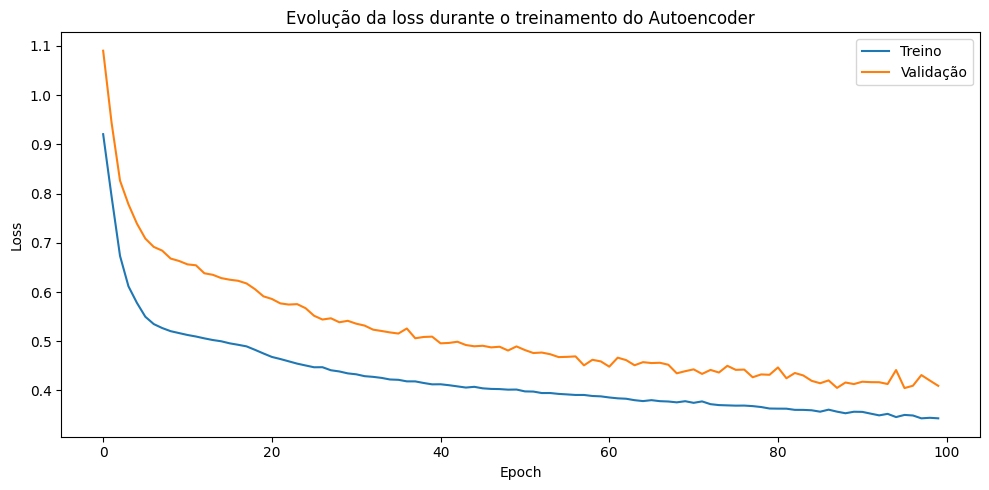

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(history_autoencoder.history["loss"], label="Treino")
plt.plot(history_autoencoder.history["val_loss"], label="Validação")

plt.title("Evolução da loss durante o treinamento do Autoencoder")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

### Análise da loss do Autoencoder

O gráfico mostra que a loss do Autoencoder diminuiu ao longo das epochs, tanto no conjunto de treino quanto no conjunto de validação.

Isso indica que o modelo conseguiu aprender uma representação comprimida dos dados e melhorar gradualmente a reconstrução das variáveis de entrada.

A curva de validação ficou acima da curva de treino, o que é esperado, já que o modelo aprende diretamente com os dados de treino. Mesmo assim, as duas curvas seguem uma tendência parecida de queda, sem um afastamento extremo entre elas.

Esse comportamento sugere que o Autoencoder conseguiu capturar padrões relevantes dos dados sem apresentar um sinal forte de `overfitting`.

Com isso, podemos usar a camada `latent_space` para extrair uma versão reduzida das variáveis originais. Essa representação será útil para comparar modelos e também para preparar a etapa futura de Quantum Machine Learning.

### Extração do espaço latente

In [23]:
encoder = Model(
    inputs=autoencoder.input,
    outputs=autoencoder.get_layer("latent_space").output
)

X_train_latent = encoder.predict(X_train_scaled)
X_test_latent = encoder.predict(X_test_scaled)

print("X_train_latent:", X_train_latent.shape)
print("X_test_latent:", X_test_latent.shape)

240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step
X_train_latent: (7651, 4)
X_test_latent: (1913, 4)


### Análise da extração do espaço latente

A extração do `latent space` reduziu as variáveis de entrada de 15 dimensões para 4 dimensões.

O conjunto de treino passou a ter o formato `(7651, 4)` e o conjunto de teste ficou com `(1913, 4)`. Isso significa que cada objeto observado agora é representado por apenas 4 características aprendidas pelo Autoencoder.

Essa redução é importante porque cria uma representação mais compacta dos dados, tentando preservar os principais padrões das variáveis originais. Além disso, esse espaço latente será útil na próxima etapa do projeto, pois modelos de Quantum Machine Learning costumam ser mais viáveis quando trabalham com poucas variáveis.

Com isso, o Autoencoder passa a funcionar como uma ponte entre Deep Learning e o futuro experimento com Quantum Machine Learning.

### Salvamento das representações latentes

In [24]:
latent_train_df = pd.DataFrame(
    X_train_latent,
    columns=[f"latent_feature_{i+1}" for i in range(X_train_latent.shape[1])]
)

latent_test_df = pd.DataFrame(
    X_test_latent,
    columns=[f"latent_feature_{i+1}" for i in range(X_test_latent.shape[1])]
)

latent_train_df["target"] = y_train
latent_test_df["target"] = y_test

latent_train_df.to_csv("../data/processed/latent_train_features.csv", index=False)
latent_test_df.to_csv("../data/processed/latent_test_features.csv", index=False)

print("Arquivos salvos em data/processed.")

Arquivos salvos em data/processed.


### Conclusão do notebook de Deep Learning e Autoencoder

Neste notebook, foram aplicadas técnicas de Deep Learning ao problema de classificação dos objetos observados pela missão Kepler.

A primeira abordagem foi uma MLP simples, treinada com as variáveis selecionadas e normalizadas. O modelo apresentou accuracy de aproximadamente 72,61%, ficando abaixo do `Random Forest`, mas acima de alguns modelos clássicos testados anteriormente.

Em seguida, foi treinada uma segunda MLP com `class_weight`, buscando melhorar o desempenho na classe `CANDIDATE`. Essa abordagem reduziu a accuracy geral para aproximadamente 67,96%, mas aumentou o recall da classe `CANDIDATE`, mostrando que o modelo passou a identificar mais candidatos reais.

Esse resultado revelou um trade-off importante: melhorar a sensibilidade para candidatos pode reduzir o desempenho geral do modelo e aumentar a confusão com outras classes.

Além das MLPs, foi construído um Autoencoder para aprender uma representação mais compacta dos dados. O modelo reduziu as 15 variáveis originais para 4 variáveis latentes, formando um `latent space` que preserva parte dos padrões aprendidos nos dados.

Essa representação latente foi salva para ser usada no próximo notebook, dedicado ao experimento de Quantum Machine Learning. Assim, o Autoencoder funciona como uma ponte entre Deep Learning e computação quântica, permitindo trabalhar com uma versão menor e mais viável dos dados.

Até esta etapa, o `Random Forest` continua sendo o melhor modelo geral em termos de accuracy, enquanto a MLP com `class_weight` trouxe uma discussão importante sobre o equilíbrio entre desempenho geral e identificação de candidatos.